Total stocks: 120



[**********************59%***                    ]  71 of 120 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: LTIM.NS"}}}
[**********************75%***********            ]  90 of 120 completedERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
[*********************100%***********************]  120 of 120 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['LTIM.NS', 'TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')



Download complete!
Stocks downloaded: 118
Stocks after cleaning: 116
Weekly observations: 267
Return matrix: (266, 116)


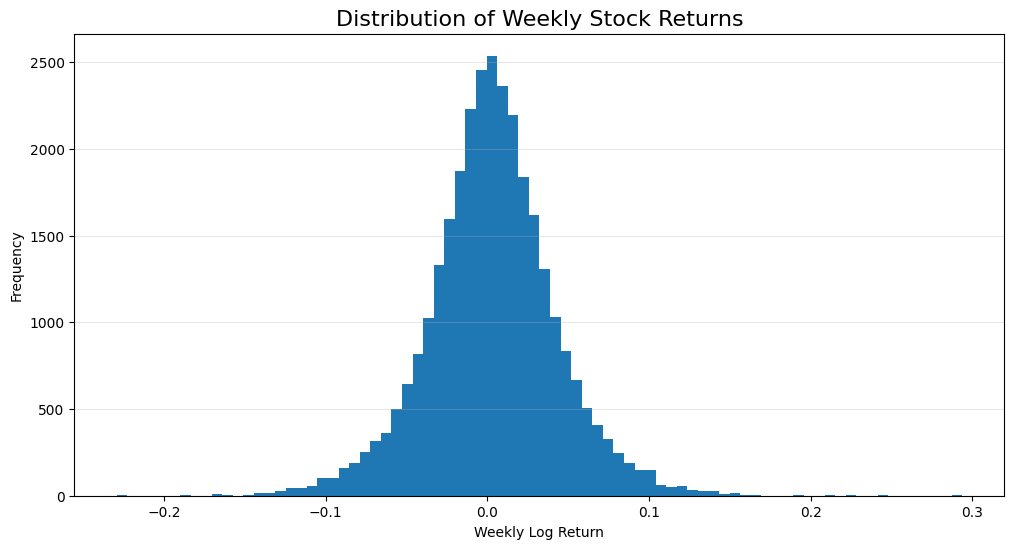

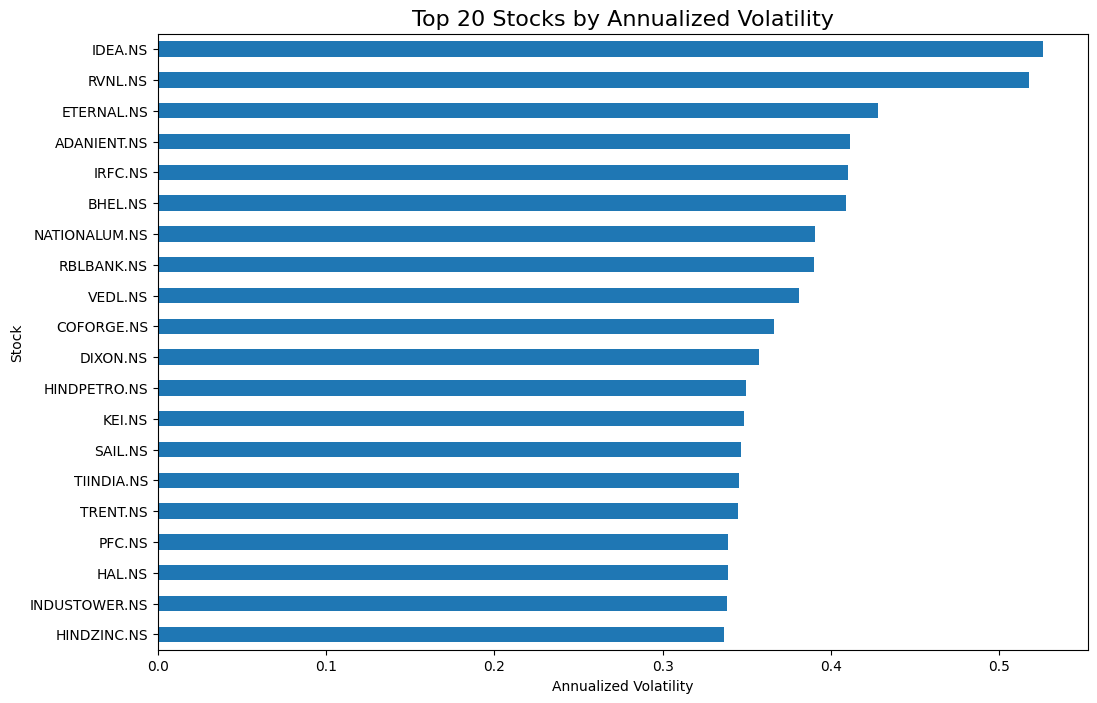

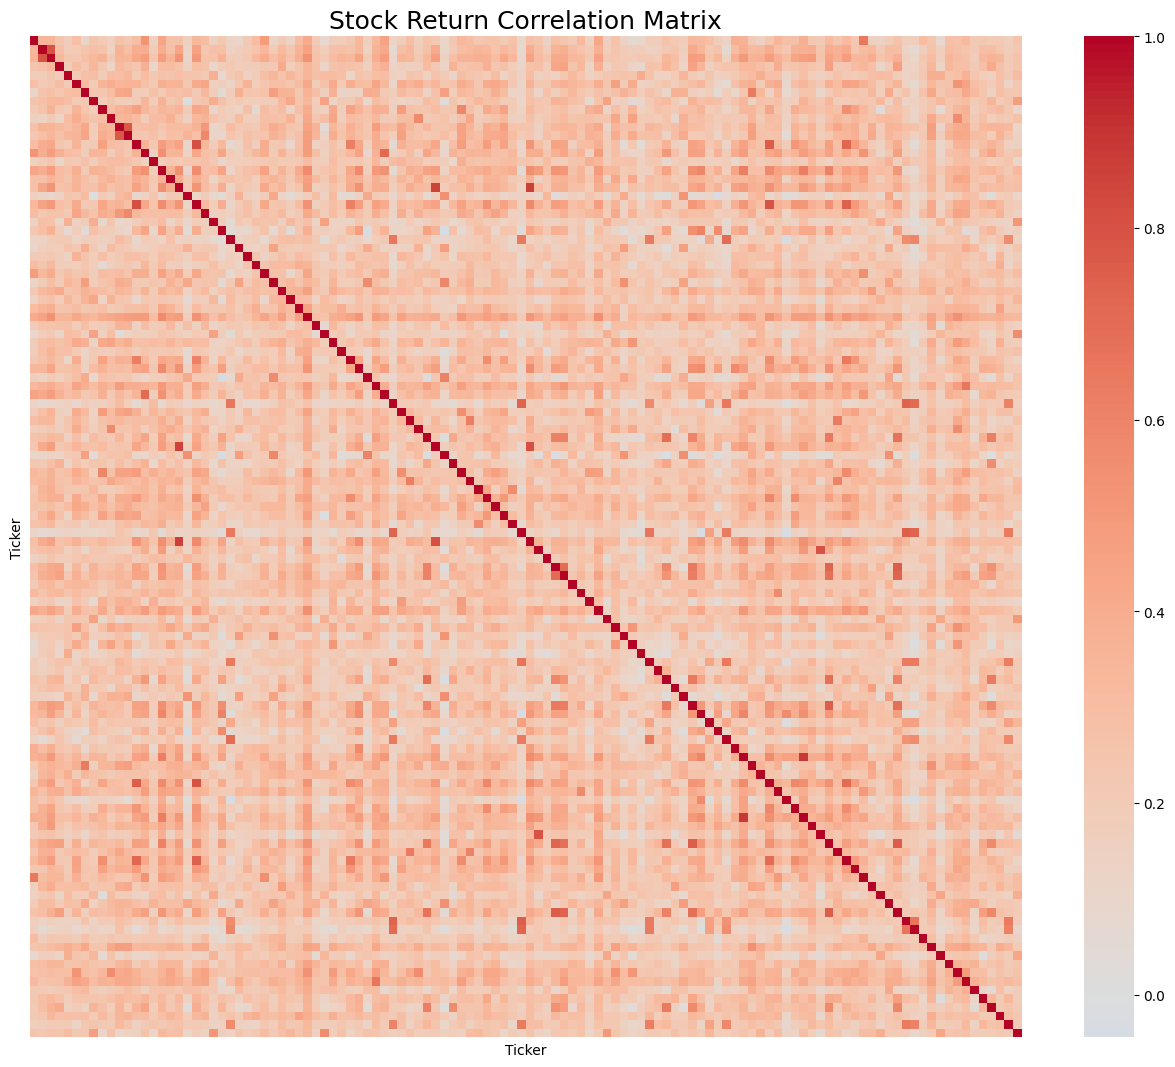

,Component,Eigenvalue,Explained Variance (%),Cumulative Variance (%)
0,PC1,32.576,27.977,27.977
1,PC2,6.641,5.703,33.680
2,PC3,5.094,4.375,38.055
3,PC4,3.796,3.260,41.315
4,PC5,2.825,2.426,43.741
5,PC6,2.537,2.178,45.919
6,PC7,2.283,1.960,47.880
7,PC8,2.119,1.820,49.700
8,PC9,2.051,1.761,51.461
9,PC10,1.857,1.595,53.056


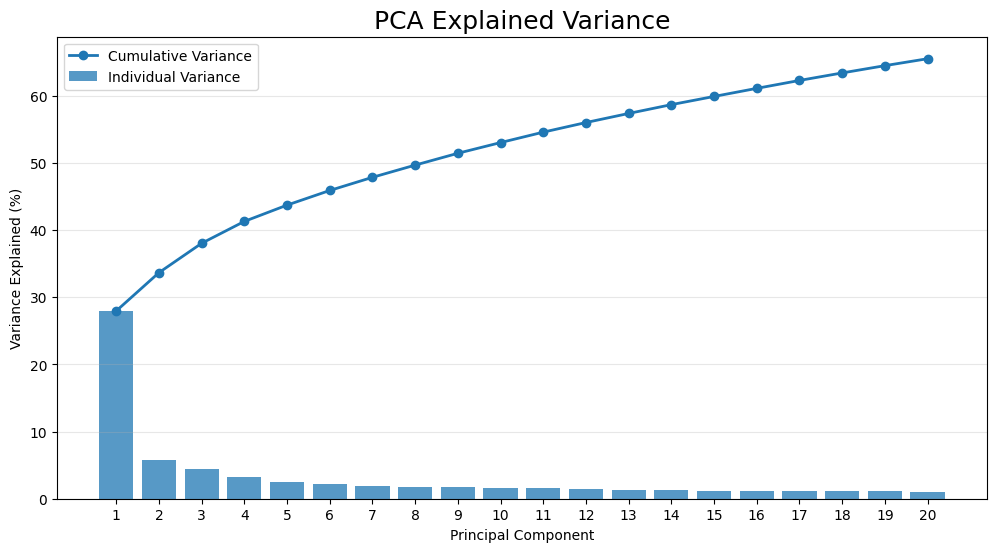


PC1 explains 27.98% of variance
Top 5 PCs explain 43.74% of variance

========== PC1 ==========

Top positive loadings:
Ticker
DLF.NS       0.1347
BHEL.NS      0.1220
CANBK.NS     0.1213
GRASIM.NS    0.1201
SAIL.NS      0.1181
IOC.NS       0.1175
PFC.NS       0.1174
PNB.NS       0.1171
SBIN.NS      0.1161
LT.NS        0.1159
Name: PC1, dtype: float64

Top negative loadings:
Ticker
MAXHEALTH.NS     0.0555
BRITANNIA.NS     0.0564
TECHM.NS         0.0567
INFY.NS          0.0587
HINDUNILVR.NS    0.0619
TORNTPHARM.NS    0.0624
HCLTECH.NS       0.0626
DRREDDY.NS       0.0635
CIPLA.NS         0.0657
MARICO.NS        0.0664
Name: PC1, dtype: float64

========== PC2 ==========

Top positive loadings:
Ticker
HINDUNILVR.NS    0.2134
NESTLEIND.NS     0.1792
BRITANNIA.NS     0.1682
GODREJCP.NS      0.1654
ASIANPAINT.NS    0.1643
DABUR.NS         0.1569
MARICO.NS        0.1541
TATACONSUM.NS    0.1405
PIDILITIND.NS    0.1328
COLPAL.NS        0.1292
Name: PC2, dtype: float64

Top negative loadings:
T

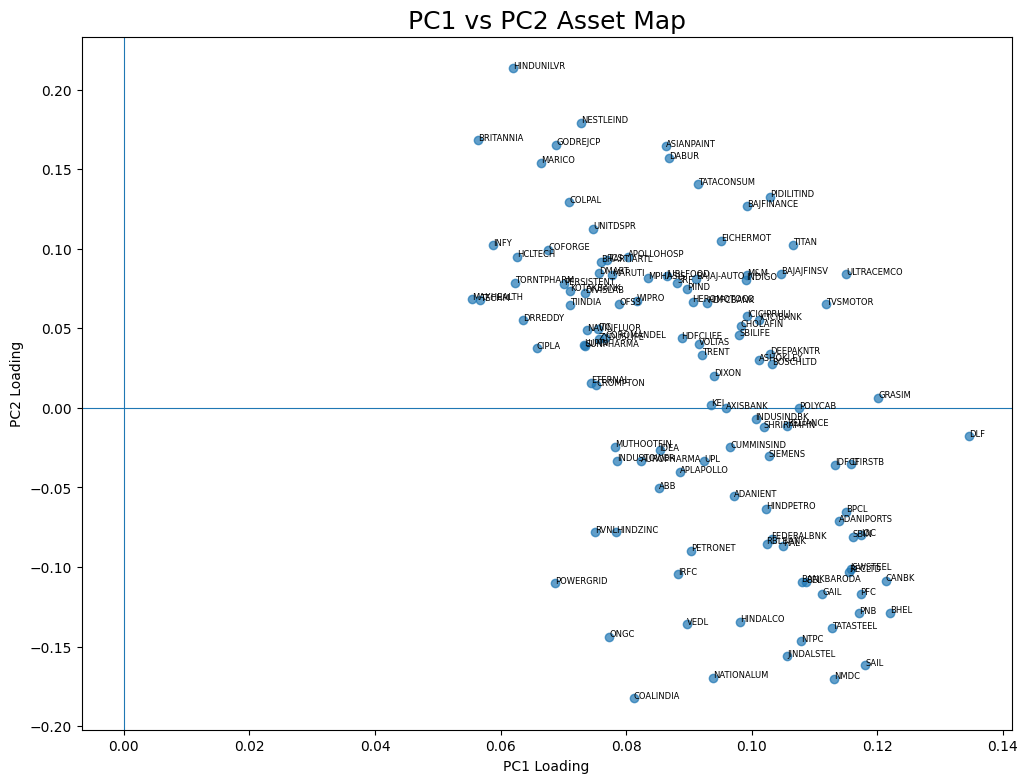

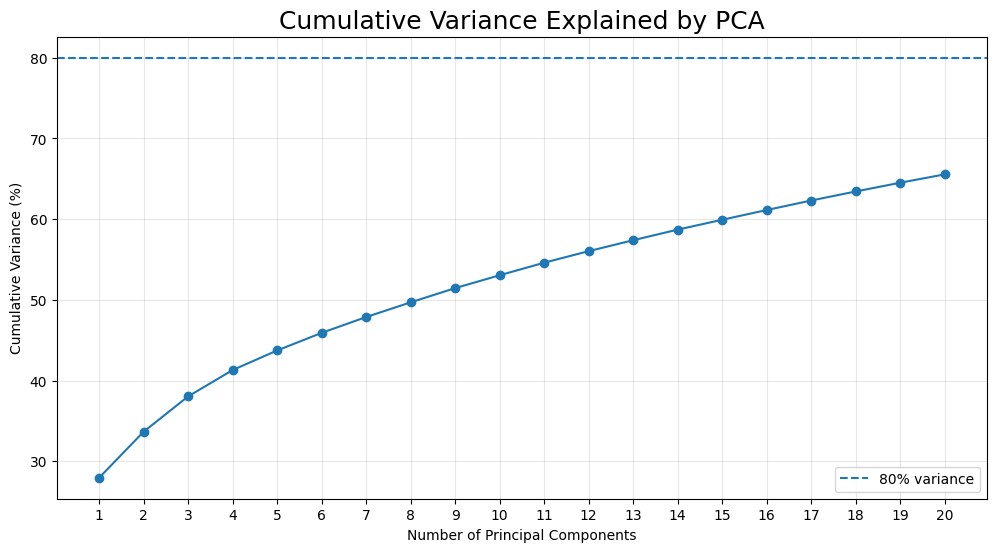

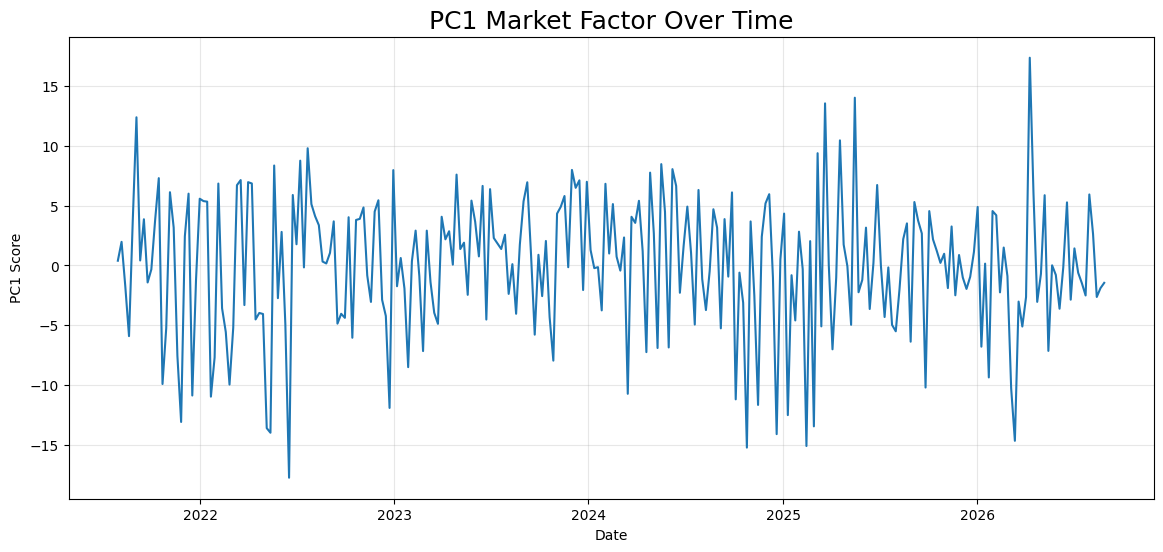

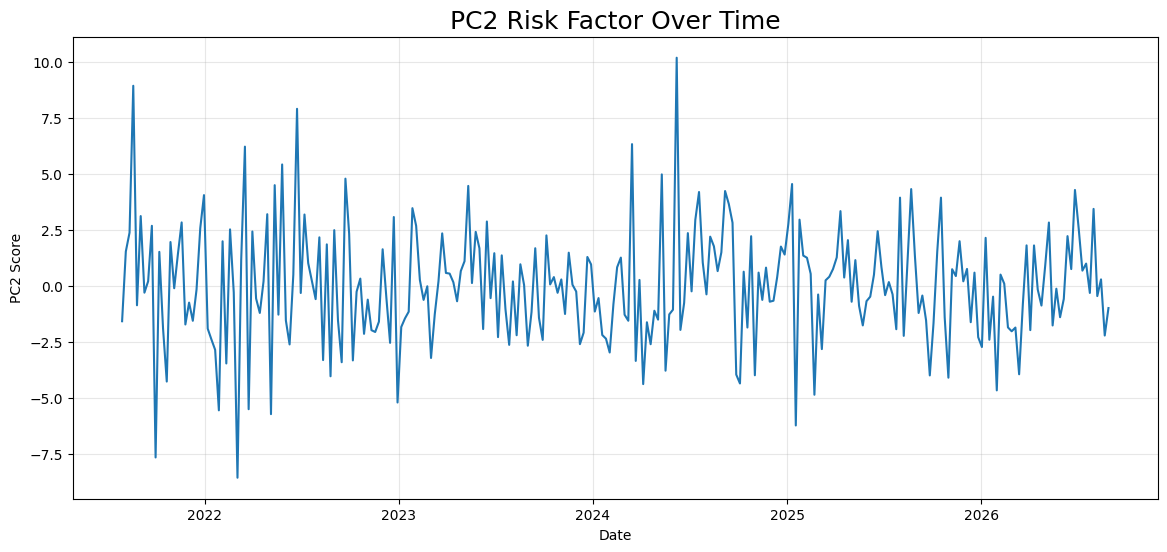




FINAL PCA SUMMARY
Original assets: 120
Usable assets: 116
Weekly observations: 266
PC1 variance: 27.98%
Top 5 variance: 43.74%


In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================================
# SETTINGS
# ============================================================

START_DATE = "2021-01-01"
END_DATE = None

TOP_K = 5

# ============================================================
# 120 STOCKS
# ============================================================

TICKERS = [
    # IT
    "TCS.NS", "INFY.NS", "HCLTECH.NS", "WIPRO.NS", "TECHM.NS",
    "LTIM.NS", "PERSISTENT.NS", "COFORGE.NS", "MPHASIS.NS", "OFSS.NS",

    # BANKING
    "HDFCBANK.NS", "ICICIBANK.NS", "SBIN.NS", "KOTAKBANK.NS",
    "AXISBANK.NS", "INDUSINDBK.NS", "BANKBARODA.NS", "CANBK.NS",
    "PNB.NS", "IDFCFIRSTB.NS", "FEDERALBNK.NS", "RBLBANK.NS",

    # FINANCIAL SERVICES
    "BAJFINANCE.NS", "BAJAJFINSV.NS", "JIOFIN.NS", "SHRIRAMFIN.NS",
    "CHOLAFIN.NS", "MUTHOOTFIN.NS", "HDFCLIFE.NS", "SBILIFE.NS",
    "ICICIPRULI.NS", "LICI.NS",

    # ENERGY
    "RELIANCE.NS", "ONGC.NS", "IOC.NS", "BPCL.NS", "HINDPETRO.NS",
    "GAIL.NS", "PETRONET.NS", "NTPC.NS", "POWERGRID.NS", "COALINDIA.NS",

    # AUTOMOBILE
    "MARUTI.NS", "TATAMOTORS.NS", "M&M.NS", "EICHERMOT.NS",
    "HEROMOTOCO.NS", "BAJAJ-AUTO.NS", "TVSMOTOR.NS", "ASHOKLEY.NS",
    "BOSCHLTD.NS", "TIINDIA.NS",

    # PHARMA
    "SUNPHARMA.NS", "DRREDDY.NS", "CIPLA.NS", "DIVISLAB.NS",
    "APOLLOHOSP.NS", "MAXHEALTH.NS", "TORNTPHARM.NS", "ZYDUSLIFE.NS",
    "LUPIN.NS", "AUROPHARMA.NS",

    # FMCG
    "HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS", "BRITANNIA.NS",
    "DABUR.NS", "MARICO.NS", "COLPAL.NS", "GODREJCP.NS",
    "TATACONSUM.NS", "UNITDSPR.NS",

    # METALS
    "TATASTEEL.NS", "JSWSTEEL.NS", "HINDALCO.NS", "JINDALSTEL.NS",
    "SAIL.NS", "VEDL.NS", "NMDC.NS", "NATIONALUM.NS",
    "HINDZINC.NS", "APLAPOLLO.NS",

    # INDUSTRIALS
    "LT.NS", "ADANIENT.NS", "ADANIPORTS.NS", "BEL.NS", "HAL.NS",
    "BHEL.NS", "SIEMENS.NS", "ABB.NS", "CUMMINSIND.NS", "RVNL.NS",

    # CONSUMER
    "TITAN.NS", "ASIANPAINT.NS", "ULTRACEMCO.NS", "GRASIM.NS",
    "DLF.NS", "TRENT.NS", "PIDILITIND.NS", "INDIGO.NS",
    "DMART.NS", "JUBLFOOD.NS",

    # TELECOM
    "BHARTIARTL.NS", "ETERNAL.NS", "INDUSTOWER.NS", "IDEA.NS",

    # CHEMICALS
    "UPL.NS", "PIIND.NS", "SRF.NS", "COROMANDEL.NS",
    "DEEPAKNTR.NS", "NAVINFLUOR.NS",

    # FINANCIAL INFRA
    "RECLTD.NS", "PFC.NS", "IRFC.NS",

    # ELECTRICAL
    "DIXON.NS", "POLYCAB.NS", "KEI.NS", "CROMPTON.NS", "VOLTAS.NS"
]

# Remove duplicates
TICKERS = list(dict.fromkeys(TICKERS))

print("Total stocks:", len(TICKERS))


# ============================================================
# DOWNLOAD DATA
# ============================================================

print("\nDownloading stock data...")

data = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    progress=True,
    threads=True
)

print("\nDownload complete!")


# ============================================================
# GET CLOSE PRICES
# ============================================================

if isinstance(data.columns, pd.MultiIndex):

    prices = data["Close"]

else:

    prices = data[["Close"]]
    prices.columns = [TICKERS[0]]


# Remove completely empty stocks
prices = prices.dropna(
    axis=1,
    how="all"
)

print(
    "Stocks downloaded:",
    prices.shape[1]
)


# ============================================================
# CLEAN DATA
# ============================================================

prices = prices.ffill(limit=3)

prices = prices.dropna(
    axis=1,
    thresh=int(len(prices) * 0.90)
)

prices = prices.dropna(
    how="any"
)

print(
    "Stocks after cleaning:",
    prices.shape[1]
)


# ============================================================
# WEEKLY DATA
# ============================================================

weekly_prices = (
    prices
    .resample("W-FRI")
    .last()
    .dropna()
)

print(
    "Weekly observations:",
    len(weekly_prices)
)


# ============================================================
# LOG RETURNS
# ============================================================

returns = np.log(
    weekly_prices /
    weekly_prices.shift(1)
)

returns = returns.dropna()

print(
    "Return matrix:",
    returns.shape
)


# ============================================================
# OUTLIER TREATMENT
# ============================================================

lower = returns.quantile(0.01)
upper = returns.quantile(0.99)

returns_clean = returns.clip(
    lower=lower,
    upper=upper,
    axis="columns"
)


# ============================================================
# GRAPH 1
# RETURN DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

plt.hist(
    returns_clean.stack(),
    bins=80
)

plt.title(
    "Distribution of Weekly Stock Returns",
    fontsize=16
)

plt.xlabel(
    "Weekly Log Return"
)

plt.ylabel(
    "Frequency"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# GRAPH 2
# STOCK VOLATILITY
# ============================================================

volatility = (
    returns_clean.std()
    *
    np.sqrt(52)
)

top_volatility = (
    volatility
    .sort_values(
        ascending=False
    )
    .head(20)
)


plt.figure(figsize=(12,8))

top_volatility.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 Stocks by Annualized Volatility",
    fontsize=16
)

plt.xlabel(
    "Annualized Volatility"
)

plt.ylabel(
    "Stock"
)

plt.show()


# ============================================================
# GRAPH 3
# CORRELATION HEATMAP
# ============================================================

correlation = returns_clean.corr()


plt.figure(figsize=(16,13))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    xticklabels=False,
    yticklabels=False
)

plt.title(
    "Stock Return Correlation Matrix",
    fontsize=18
)

plt.show()


# ============================================================
# STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X = scaler.fit_transform(
    returns_clean
)


# ============================================================
# PCA
# ============================================================

n_components = min(
    20,
    X.shape[0],
    X.shape[1]
)

pca = PCA(
    n_components=n_components
)

scores = pca.fit_transform(
    X
)


explained_variance = (
    pca.explained_variance_ratio_
    * 100
)

cumulative_variance = np.cumsum(
    explained_variance
)


# ============================================================
# PCA RESULTS TABLE
# ============================================================

pca_results = pd.DataFrame({

    "Component": [
        f"PC{i+1}"
        for i in range(n_components)
    ],

    "Eigenvalue":
        pca.explained_variance_,

    "Explained Variance (%)":
        explained_variance,

    "Cumulative Variance (%)":
        cumulative_variance

})


display(
    pca_results.round(3)
)


# ============================================================
# GRAPH 4
# PCA EXPLAINED VARIANCE
# ============================================================

plt.figure(figsize=(12,6))

x = np.arange(
    1,
    n_components + 1
)

plt.bar(
    x,
    explained_variance,
    alpha=0.75,
    label="Individual Variance"
)

plt.plot(
    x,
    cumulative_variance,
    marker="o",
    linewidth=2,
    label="Cumulative Variance"
)

plt.xlabel(
    "Principal Component"
)

plt.ylabel(
    "Variance Explained (%)"
)

plt.title(
    "PCA Explained Variance",
    fontsize=18
)

plt.xticks(x)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# PRINT MAIN PCA RESULT
# ============================================================

print("\n========================================")

print(
    f"PC1 explains "
    f"{explained_variance[0]:.2f}% of variance"
)

print(
    f"Top 5 PCs explain "
    f"{cumulative_variance[4]:.2f}% of variance"
)

print("========================================")


# ============================================================
# PCA LOADINGS
# ============================================================

loadings = pd.DataFrame(

    pca.components_.T,

    index=returns_clean.columns,

    columns=[
        f"PC{i+1}"
        for i in range(n_components)
    ]

)


# ============================================================
# TOP LOADINGS
# ============================================================

for pc in [
    "PC1",
    "PC2",
    "PC3",
    "PC4"
]:

    print(
        f"\n========== {pc} =========="
    )

    print("\nTop positive loadings:")

    print(
        loadings[pc]
        .sort_values(
            ascending=False
        )
        .head(10)
        .round(4)
    )

    print("\nTop negative loadings:")

    print(
        loadings[pc]
        .sort_values()
        .head(10)
        .round(4)
    )


# ============================================================
# GRAPH 5
# PC1 vs PC2
# ============================================================

plt.figure(figsize=(12,9))

plt.scatter(
    loadings["PC1"],
    loadings["PC2"],
    alpha=0.7
)

for stock in loadings.index:

    plt.annotate(
        stock.replace(".NS", ""),
        (
            loadings.loc[
                stock,
                "PC1"
            ],

            loadings.loc[
                stock,
                "PC2"
            ]
        ),
        fontsize=6
    )


plt.axhline(
    0,
    linewidth=0.8
)

plt.axvline(
    0,
    linewidth=0.8
)

plt.xlabel(
    "PC1 Loading"
)

plt.ylabel(
    "PC2 Loading"
)

plt.title(
    "PC1 vs PC2 Asset Map",
    fontsize=18
)

plt.show()


# ============================================================
# GRAPH 6
# CUMULATIVE VARIANCE
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    x,
    cumulative_variance,
    marker="o"
)

plt.axhline(
    80,
    linestyle="--",
    label="80% variance"
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Variance (%)"
)

plt.title(
    "Cumulative Variance Explained by PCA",
    fontsize=18
)

plt.xticks(x)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# GRAPH 7
# PORTFOLIO FACTOR SCORES
# ============================================================

factor_scores = pd.DataFrame(

    scores,

    index=returns_clean.index,

    columns=[
        f"PC{i+1}"
        for i in range(n_components)
    ]

)


plt.figure(figsize=(14,6))

plt.plot(
    factor_scores.index,
    factor_scores["PC1"]
)

plt.title(
    "PC1 Market Factor Over Time",
    fontsize=18
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "PC1 Score"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# GRAPH 8
# PC2 FACTOR
# ============================================================

plt.figure(figsize=(14,6))

plt.plot(
    factor_scores.index,
    factor_scores["PC2"]
)

plt.title(
    "PC2 Risk Factor Over Time",
    fontsize=18
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "PC2 Score"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n\n")
print("=" * 70)
print("FINAL PCA SUMMARY")
print("=" * 70)

print(
    "Original assets:",
    len(TICKERS)
)

print(
    "Usable assets:",
    returns_clean.shape[1]
)

print(
    "Weekly observations:",
    returns_clean.shape[0]
)

print(
    f"PC1 variance: "
    f"{explained_variance[0]:.2f}%"
)

print(
    f"Top 5 variance: "
    f"{cumulative_variance[4]:.2f}%"
)

print("=" * 70)